## IMPORT

In [1]:
!pip3 install kagglehub
!pip3 install pandas

import kagglehub
import os
import pandas as pd

path = kagglehub.dataset_download("yapwh1208/supermarket-sales-data")

print("Path to dataset files:", path)
print(os.listdir(path))

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


/Users/ahmad/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/ahmad/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/ahmad/.cache/kagglehub/datasets/yapwh1208/supermarket-sales-data/versions/3
['annex4.csv', 'annex3.csv', 'annex2.csv', 'annex1.csv']


In [2]:
# Load the dataset files into pandas DataFrames
category_df = pd.read_csv(f"{path}/annex1.csv")
transaction_df = pd.read_csv(f"{path}/annex2.csv")
wholesale_df = pd.read_csv(f"{path}/annex3.csv")
loss_rate_df = pd.read_csv(f"{path}/annex4.csv")

In [3]:
# Display info about the DataFrames
category_df.info()
transaction_df.info()
wholesale_df.info()
loss_rate_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Item Code      251 non-null    int64 
 1   Item Name      251 non-null    object
 2   Category Code  251 non-null    int64 
 3   Category Name  251 non-null    object
dtypes: int64(2), object(2)
memory usage: 8.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 878503 entries, 0 to 878502
Data columns (total 7 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Date                         878503 non-null  object 
 1   Time                         878503 non-null  object 
 2   Item Code                    878503 non-null  int64  
 3   Quantity Sold (kilo)         878503 non-null  float64
 4   Unit Selling Price (RMB/kg)  878503 non-null  float64
 5   Sale or Return               878503 non-null  object 
 6   D

## EDA

### Category Table

In [4]:
category_df.head(15)

,Item Code,Item Name,Category Code,Category Name
0,102900005115168,Niushou Shengcai,1011010101,Flower/Leaf Vegetables
1,102900005115199,Sichuan Red Cedar,1011010101,Flower/Leaf Vegetables
2,102900005115625,Local Xiaomao Cabbage,1011010101,Flower/Leaf Vegetables
3,102900005115748,White Caitai,1011010101,Flower/Leaf Vegetables
4,102900005115762,Amaranth,1011010101,Flower/Leaf Vegetables
5,102900005115779,Yunnan Shengcai,1011010101,Flower/Leaf Vegetables
6,102900005115786,Zhuyecai,1011010101,Flower/Leaf Vegetables
7,102900005115793,Chinese Cabbage,1011010101,Flower/Leaf Vegetables
8,102900005115816,Nanguajian,1011010101,Flower/Leaf Vegetables
9,102900005115823,Shanghaiqing,1011010101,Flower/Leaf Vegetables


In [5]:
# Checking duplicate values in item names
duplicate_names = category_df[category_df['Item Name'].duplicated(keep=False)]
duplicate_names.sort_values('Item Name')

,Item Code,Item Name,Category Code,Category Name
201,102900011012994,Apricot Bao Mushroom (Bag),1011010801,Edible Mushroom
215,102900011031599,Apricot Bao Mushroom (Bag),1011010801,Edible Mushroom
94,102900051000890,Broccoli,1011010101,Flower/Leaf Vegetables
100,102900005116714,Broccoli,1011010201,Cabbage
7,102900005115793,Chinese Cabbage,1011010101,Flower/Leaf Vegetables
16,102900005115960,Chinese Cabbage,1011010101,Flower/Leaf Vegetables
203,102900011018095,Chinese Caterpillar Fungus Flowers (Bag),1011010801,Edible Mushroom
218,102900011031926,Chinese Caterpillar Fungus Flowers (Bag),1011010801,Edible Mushroom


In [6]:
# Data Quality Note: "Broccoli" had two SKUs with inconsistent categories
# (Flower/Leaf Vegetables vs. Cabbage). Isolated case (confirmed via
# groupby check). Standardized both to "Cabbage" for consistent
# category-level aggregation downstream.

category_df.loc[category_df['Item Name'] == 'Broccoli', 'Category Code'] = 1011010201
category_df.loc[category_df['Item Name'] == 'Broccoli', 'Category Name'] = 'Cabbage'

In [7]:
# Verify that the Broccoli category has been standardized to Cabbage
category_df[category_df['Item Name'] == 'Broccoli']

,Item Code,Item Name,Category Code,Category Name
94,102900051000890,Broccoli,1011010201,Cabbage
100,102900005116714,Broccoli,1011010201,Cabbage


In [8]:
# Checking duplicate item codes
duplicate_codes = category_df[category_df['Item Code'].duplicated(keep=False)]
duplicate_codes.sort_values('Item Code')

,Item Code,Item Name,Category Code,Category Name


### Transactions Table

In [9]:
transaction_df.describe()

,Item Code,Quantity Sold (kilo),Unit Selling Price (RMB/kg)
count,8.785030e+05,878503.000000,878503.000000
mean,1.030313e+14,0.536112,8.917144
std,7.174368e+11,0.400087,6.311265
min,1.029000e+14,-9.082000,0.100000
25%,1.029000e+14,0.290000,4.900000
50%,1.029000e+14,0.435000,7.900000
75%,1.029000e+14,0.742000,10.800000
max,1.069740e+14,160.000000,119.900000


In [10]:
# Checking for missing values in the transaction DataFrame
transaction_df.isnull().sum()

Date                           0
Time                           0
Item Code                      0
Quantity Sold (kilo)           0
Unit Selling Price (RMB/kg)    0
Sale or Return                 0
Discount (Yes/No)              0
dtype: int64

In [11]:
# Data Quality Note: There are transactions with negative quantity sold. These are likely returns or data entry errors
transactions_less_than_zero = transaction_df[transaction_df['Quantity Sold (kilo)'] < 0]
transactions_less_than_zero.head(10)

,Date,Time,Item Code,Quantity Sold (kilo),Unit Selling Price (RMB/kg),Sale or Return,Discount (Yes/No)
357,2020-07-01,12:46:28.030,102900005116714,-0.436,14.0,return,No
2929,2020-07-03,21:10:46.405,102900005118831,-1.000,6.9,return,No
6991,2020-07-07,17:45:51.373,102900005118831,-1.000,6.5,return,No
7090,2020-07-07,18:33:03.608,102900005118831,-1.000,6.9,return,No
7242,2020-07-07,20:11:11.701,102900005118831,-1.000,6.9,return,No
7420,2020-07-08,10:03:17.264,102900005118831,-2.000,6.9,return,No
7426,2020-07-08,10:05:57.420,102900005118831,-1.000,6.9,return,No
7443,2020-07-08,10:11:26.436,102900005118831,-1.000,6.9,return,No
7692,2020-07-08,12:42:50.326,102900005118831,-1.000,6.9,return,No
7703,2020-07-08,13:17:06.170,102900005118831,-1.000,6.9,return,No


In [12]:
# Rows where quantity sold is exactly 0
zero_qty_df = transaction_df[transaction_df['Quantity Sold (kilo)'] == 0]
zero_qty_df.head(10)

,Date,Time,Item Code,Quantity Sold (kilo),Unit Selling Price (RMB/kg),Sale or Return,Discount (Yes/No)


In [13]:
# Checking for negative quantity sold transactions that are marked as sales (not returns)
transactions_less_than_zero = transaction_df[(transaction_df['Quantity Sold (kilo)'] < 0) & (transaction_df['Sale or Return'] == 'sale')]
transactions_less_than_zero.head(10)

,Date,Time,Item Code,Quantity Sold (kilo),Unit Selling Price (RMB/kg),Sale or Return,Discount (Yes/No)


In [14]:
# Checking the distribution of Sale or Return values
transaction_df['Sale or Return'].value_counts()

Sale or Return
sale      878042
return       461
Name: count, dtype: int64

### Wholesale Table

In [15]:
wholesale_df.describe()

,Item Code,Wholesale Price (RMB/kg)
count,5.598200e+04,55982.000000
mean,1.030449e+14,5.962620
std,7.527927e+11,5.067802
min,1.029000e+14,0.010000
25%,1.029000e+14,2.810000
50%,1.029000e+14,4.630000
75%,1.029000e+14,7.570000
max,1.069740e+14,141.000000


In [16]:
# Checking for missing values in the wholesale DataFrame
wholesale_df.isnull().sum()

Date                        0
Item Code                   0
Wholesale Price (RMB/kg)    0
dtype: int64

In [17]:
# Check for duplicate Item Codes in wholesale_df
duplicate_wholesale = wholesale_df[wholesale_df['Item Code'].duplicated(keep=False)]
duplicate_wholesale.sort_values('Item Code')

,Date,Item Code,Wholesale Price (RMB/kg)
26760,2022-01-03,102900005115168,2.60
54244,2023-05-27,102900005115168,2.20
15536,2021-06-08,102900005115168,1.40
15586,2021-06-09,102900005115168,1.40
13948,2021-05-05,102900005115168,0.88
...,...,...,...
38150,2022-07-10,106973990980123,1.59
38078,2022-07-09,106973990980123,1.50
39132,2022-07-26,106973990980123,1.90
38663,2022-07-18,106973990980123,1.67


In [18]:
# Check if (Item Code, Date) combination is unique
# This is to confirm if there is an entry error OR items have been bought at different prices on different days
wholesale_df.duplicated(subset=['Item Code', 'Date']).sum()

np.int64(0)

In [19]:
# Check the date range in wholesale_df
print(wholesale_df['Date'].min())
print(wholesale_df['Date'].max())
print(wholesale_df['Date'].nunique())

2020-07-01
2023-06-30
1091


### Loss rate Table

In [20]:
# Checking for missing values in the loss rate DataFrame
loss_rate_df.isnull().sum()

Item Code        0
Item Name        0
Loss Rate (%)    0
dtype: int64

In [21]:
# Checking for duplicate Item Codes in loss_rate_df
duplicate_loss_rate = loss_rate_df[loss_rate_df['Item Code'].duplicated(keep=False)]
duplicate_loss_rate.sort_values('Item Code')

,Item Code,Item Name,Loss Rate (%)


In [22]:
# Top 5 highest loss rate
top5_highest_loss = loss_rate_df.sort_values('Loss Rate (%)', ascending=False).head(5)
top5_highest_loss

,Item Code,Item Name,Loss Rate (%)
43,102900005118824,High Melon (1),29.25
181,102900011033081,Chuncai,29.03
67,102900011006689,Dongmenkou Xiaobaicai,27.84
68,102900011006948,Foreign Garland Chrysanthemum,26.16
59,102900011000632,Purple Cabbage (1),25.53


In [23]:
# Top 5 lowest non-zero loss rate
top5_lowest_nonzero = loss_rate_df[loss_rate_df['Loss Rate (%)'] > 0].sort_values('Loss Rate (%)', ascending=True).head(5)
top5_lowest_nonzero

,Item Code,Item Name,Loss Rate (%)
32,102900005116806,Black Rapeseed,0.10
250,106973990980123,Hfyg Haixian Mushroom (Bunch),0.12
3,102900005115625,Local Xiaomao Cabbage,0.18
127,102900011029305,Fruit Chili,0.18
205,102900011034330,Agaricus Bisporus (Box),0.20


In [24]:
# Percentage of items with zero loss rate
(loss_rate_df['Loss Rate (%)'] == 0).mean() * 100

np.float64(8.764940239043826)

In [25]:
# Identifying items with zero loss rate
zero_loss_items = loss_rate_df[loss_rate_df['Loss Rate (%)'] == 0][['Item Code', 'Item Name']]

# Merge to bring in transaction counts per item, keeping the name attached
zero_loss_txn_counts = transaction_df[transaction_df['Item Code'].isin(zero_loss_items['Item Code'])] \
    .groupby('Item Code').size().reset_index(name='transaction_count')

zero_loss_summary = zero_loss_items.merge(zero_loss_txn_counts, on='Item Code', how='left')
zero_loss_summary.sort_values('transaction_count', ascending=False).head(10)

,Item Code,Item Name,transaction_count
20,106971533450003,Haixian Mushroom (Bunch),1300
17,106930274620090,Haixian Mushroom (Bag) (2),709
1,102900011029176,Lameizi,455
18,106957634300010,The White Mushroom (Box),164
19,106957634300058,The Crab Flavor Mushroom (Box),81
13,102900011034354,Xianzongye (Bag) (1),41
9,102900011032282,Xiangtianhongcaitai (Bag),41
14,102900011035849,Chinese Cabbage Seedling,39
16,102900051006229,Lotus Root Tip,34
2,102900011029299,Purple Screw Pepper,29


In [26]:
# Data Quality Note: 8.76% of items show exactly 0% loss rate.
# Most are low-volume items (plausible). 
# Two high-volume exceptions — Haixian Mushroom (Bag)(2) and (Bunch), 709 & 1,300 transactions
# They are implausible for a perishable product and likely reflect missing/unrecorded loss data.
# Decision: To exclude them from loss-rate-based rankings and aggregations; kept in all other analyses (sales volume, revenue).

## SQL

### SETUP

In [27]:
!pip3 install duckdb -q
import duckdb
con = duckdb.connect()   # in-memory database — resets when your session ends

con.register("category", category_df)
con.register("transactions", transaction_df)
con.register("wholesale", wholesale_df)
con.register("loss_rate", loss_rate_df)

con.sql("SHOW TABLES")

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


┌──────────────┐
│     name     │
│   varchar    │
├──────────────┤
│ category     │
│ loss_rate    │
│ transactions │
│ wholesale    │
└──────────────┘

In [28]:
con.sql("SELECT * FROM category LIMIT 5")

┌─────────────────┬───────────────────────┬───────────────┬────────────────────────┐
│    Item Code    │       Item Name       │ Category Code │     Category Name      │
│      int64      │        varchar        │     int64     │        varchar         │
├─────────────────┼───────────────────────┼───────────────┼────────────────────────┤
│ 102900005115168 │ Niushou Shengcai      │    1011010101 │ Flower/Leaf Vegetables │
│ 102900005115199 │ Sichuan Red Cedar     │    1011010101 │ Flower/Leaf Vegetables │
│ 102900005115625 │ Local Xiaomao Cabbage │    1011010101 │ Flower/Leaf Vegetables │
│ 102900005115748 │ White Caitai          │    1011010101 │ Flower/Leaf Vegetables │
│ 102900005115762 │ Amaranth              │    1011010101 │ Flower/Leaf Vegetables │
└─────────────────┴───────────────────────┴───────────────┴────────────────────────┘

### Descriptive Metrics

In [29]:
# Total quanity sold and total revenue across all categories
con.sql("""
SELECT
    c."Category Name",
    SUM(t."Quantity Sold (kilo)") AS total_quantity_sold_kilo,
    SUM(t."Quantity Sold (kilo)" * t."Unit Selling Price (RMB/kg)") AS total_revenue_RMB
FROM transactions t
JOIN category c ON t."Item Code" = c."Item Code"
GROUP BY c."Category Name"
ORDER BY total_revenue_RMB DESC
""")

┌─────────────────────────────┬──────────────────────────┬────────────────────┐
│        Category Name        │ total_quantity_sold_kilo │ total_revenue_RMB  │
│           varchar           │          double          │       double       │
├─────────────────────────────┼──────────────────────────┼────────────────────┤
│ Flower/Leaf Vegetables      │       198520.30700000105 │ 1079063.0915999622 │
│ Capsicum                    │        91588.62900000054 │  754133.0166999807 │
│ Edible Mushroom             │        76086.72500000046 │  619597.7942000024 │
│ Cabbage                     │        41767.12200000026 │  375758.4150000025 │
│ Aquatic Tuberous Vegetables │       40581.353000000294 │ 350089.90070000454 │
│ Solanum                     │       22431.782000000025 │ 191124.25860000064 │
└─────────────────────────────┴──────────────────────────┴────────────────────┘

In [30]:
# Average Sale price per kilo by category
con.sql("""
SELECT
    c."Category Name",
    AVG(t."Unit Selling Price (RMB/kg)") AS avg_sale_price_per_kilo
FROM transactions t
JOIN category c ON t."Item Code" = c."Item Code"
WHERE t."Sale or Return" = 'sale'
GROUP BY c."Category Name"
ORDER BY avg_sale_price_per_kilo DESC
""")

┌─────────────────────────────┬─────────────────────────┐
│        Category Name        │ avg_sale_price_per_kilo │
│           varchar           │         double          │
├─────────────────────────────┼─────────────────────────┤
│ Edible Mushroom             │      12.035682650109496 │
│ Capsicum                    │      10.579167267934132 │
│ Aquatic Tuberous Vegetables │       9.690183065190439 │
│ Cabbage                     │       9.138103438312504 │
│ Solanum                     │       8.695182816782095 │
│ Flower/Leaf Vegetables      │       6.317173616887943 │
└─────────────────────────────┴─────────────────────────┘

In [31]:
# total transaction count by category
con.sql("""
SELECT
    c."Category Name",
    COUNT(*) AS total_transaction_count
FROM transactions t
JOIN category c ON t."Item Code" = c."Item Code"
WHERE t."Sale or Return" = 'sale'
GROUP BY c."Category Name"
ORDER BY total_transaction_count DESC
""")

┌─────────────────────────────┬─────────────────────────┐
│        Category Name        │ total_transaction_count │
│           varchar           │          int64          │
├─────────────────────────────┼─────────────────────────┤
│ Flower/Leaf Vegetables      │                  331788 │
│ Capsicum                    │                  207894 │
│ Edible Mushroom             │                  148341 │
│ Cabbage                     │                   86525 │
│ Aquatic Tuberous Vegetables │                   58613 │
│ Solanum                     │                   44881 │
└─────────────────────────────┴─────────────────────────┘

### Cost and Margin Metrics

In [32]:
# Assumption: Margin is calculated using the wholesale price recorded on the 
# same date as the sale, as a proxy for the item's cost basis. This does not 
# account for inventory holding time (e.g., an item purchased on one date and 
# sold a few days later at a different wholesale price). Given the short shelf 
# life and fast turnover typical of fresh produce, this is treated as a 
# reasonable approximation rather than an exact cost-of-goods-sold calculation.

In [33]:
# Gross Margin per category
con.sql("""
SELECT
    c."Category Name",
    AVG(t."Unit Selling Price (RMB/kg)") AS avg_sale_price_per_kilo,
    AVG(w."Wholesale Price (RMB/kg)") AS avg_wholesale_price_per_kilo,
    AVG(t."Unit Selling Price (RMB/kg)") - AVG(w."Wholesale Price (RMB/kg)") AS avg_gross_margin_per_kilo
FROM transactions t
JOIN category c ON t."Item Code" = c."Item Code"
JOIN wholesale w ON t."Item Code" = w."Item Code" AND t."Date" = w."Date"
WHERE t."Sale or Return" = 'sale'
GROUP BY c."Category Name"
ORDER BY avg_gross_margin_per_kilo DESC
""")

┌─────────────────────────────┬─────────────────────────┬──────────────────────────────┬───────────────────────────┐
│        Category Name        │ avg_sale_price_per_kilo │ avg_wholesale_price_per_kilo │ avg_gross_margin_per_kilo │
│           varchar           │         double          │            double            │          double           │
├─────────────────────────────┼─────────────────────────┼──────────────────────────────┼───────────────────────────┤
│ Edible Mushroom             │      12.035682650109496 │             7.70421609669618 │         4.331466553413317 │
│ Capsicum                    │      10.579167267934132 │            6.744899371795237 │         3.834267896138895 │
│ Cabbage                     │       9.138103438312504 │           5.9613251661369135 │          3.17677827217559 │
│ Solanum                     │       8.695182816782095 │            5.547681424210658 │        3.1475013925714377 │
│ Aquatic Tuberous Vegetables │       9.690183065190439 │       

In [34]:
# Gross Margin % by category
con.sql("""
SELECT
    c."Category Name",
    AVG(t."Unit Selling Price (RMB/kg)") AS avg_sale_price_per_kilo,
    AVG(w."Wholesale Price (RMB/kg)") AS avg_wholesale_price_per_kilo,
    (AVG(t."Unit Selling Price (RMB/kg)") - AVG(w."Wholesale Price (RMB/kg)")) / AVG(t."Unit Selling Price (RMB/kg)") * 100 AS avg_gross_margin_percent
FROM transactions t
JOIN category c ON t."Item Code" = c."Item Code"
JOIN wholesale w ON t."Item Code" = w."Item Code" AND t."Date" = w."Date"
WHERE t."Sale or Return" = 'sale'
GROUP BY c."Category Name"
ORDER BY avg_gross_margin_percent DESC
""")

┌─────────────────────────────┬─────────────────────────┬──────────────────────────────┬──────────────────────────┐
│        Category Name        │ avg_sale_price_per_kilo │ avg_wholesale_price_per_kilo │ avg_gross_margin_percent │
│           varchar           │         double          │            double            │          double          │
├─────────────────────────────┼─────────────────────────┼──────────────────────────────┼──────────────────────────┤
│ Flower/Leaf Vegetables      │       6.317173616887943 │            3.841319698120471 │        39.19243112376517 │
│ Capsicum                    │      10.579167267934132 │            6.744899371795237 │        36.24357001860355 │
│ Solanum                     │       8.695182816782095 │            5.547681424210657 │         36.1982198522223 │
│ Edible Mushroom             │      12.035682650109496 │             7.70421609669618 │         35.9885407361909 │
│ Cabbage                     │       9.138103438312504 │           5.96

In [35]:
# Revenue to cost ratio by category
con.sql("""
SELECT
    c."Category Name",
    SUM(t."Quantity Sold (kilo)" * t."Unit Selling Price (RMB/kg)") AS total_revenue_RMB,
    SUM(t."Quantity Sold (kilo)" * w."Wholesale Price (RMB/kg)") AS total_cost_RMB,
    SUM(t."Quantity Sold (kilo)" * t."Unit Selling Price (RMB/kg)") / SUM(t."Quantity Sold (kilo)" * w."Wholesale Price (RMB/kg)") AS revenue_to_cost_ratio
FROM transactions t
JOIN category c ON t."Item Code" = c."Item Code"
JOIN wholesale w ON t."Item Code" = w."Item Code" AND t."Date" = w."Date"
WHERE t."Sale or Return" = 'sale'
GROUP BY c."Category Name"
ORDER BY revenue_to_cost_ratio DESC
""")

┌─────────────────────────────┬────────────────────┬────────────────────┬───────────────────────┐
│        Category Name        │ total_revenue_RMB  │   total_cost_RMB   │ revenue_to_cost_ratio │
│           varchar           │       double       │       double       │        double         │
├─────────────────────────────┼────────────────────┼────────────────────┼───────────────────────┤
│ Flower/Leaf Vegetables      │ 1079828.1189999622 │   649282.240690002 │    1.6631105108502777 │
│ Capsicum                    │  754564.4228999807 │  474862.2497500007 │    1.5890174956995085 │
│ Edible Mushroom             │  620110.2020000023 │  394106.9467400032 │    1.5734566648202117 │
│ Solanum                     │ 191226.98340000064 │ 121809.80330000016 │    1.5698817190356664 │
│ Cabbage                     │ 375987.55390000256 │ 245007.21306000033 │    1.5345978969522265 │
│ Aquatic Tuberous Vegetables │  350306.0611000046 │ 242381.85073000035 │    1.4452652294095472 │
└───────────────────

### Loss adjusted Metrics

In [36]:
#average Loss rate by category
con.sql("""
SELECT
    c."Category Name",
    AVG(l."Loss Rate (%)") AS avg_loss_rate_percent
FROM loss_rate l
JOIN category c ON l."Item Code" = c."Item Code"
GROUP BY c."Category Name"
ORDER BY avg_loss_rate_percent DESC
""")

┌─────────────────────────────┬───────────────────────┐
│        Category Name        │ avg_loss_rate_percent │
│           varchar           │        double         │
├─────────────────────────────┼───────────────────────┤
│ Cabbage                     │     13.35666666666667 │
│ Aquatic Tuberous Vegetables │    11.974736842105266 │
│ Flower/Leaf Vegetables      │    10.288888888888877 │
│ Capsicum                    │     8.515333333333338 │
│ Edible Mushroom             │     8.130972222222221 │
│ Solanum                     │     7.121999999999998 │
└─────────────────────────────┴───────────────────────┘

In [37]:
#Loss-adjusted gross margin per category
con.sql("""
SELECT
    c."Category Name",
    AVG(t."Unit Selling Price (RMB/kg)") AS avg_sale_price_per_kilo,
    AVG(w."Wholesale Price (RMB/kg)") AS avg_wholesale_price_per_kilo,
    AVG(l."Loss Rate (%)") AS avg_loss_rate_percent,
    (AVG(t."Unit Selling Price (RMB/kg)") - AVG(w."Wholesale Price (RMB/kg)")) * (1 - AVG(l."Loss Rate (%)") / 100) AS avg_loss_adjusted_gross_margin_per_kilo
FROM transactions t
JOIN category c ON t."Item Code" = c."Item Code"
JOIN wholesale w ON t."Item Code" = w."Item Code" AND t."Date" = w."Date"
JOIN loss_rate l ON t."Item Code" = l."Item Code"
WHERE t."Sale or Return" = 'sale' AND t."Item Code" NOT IN (106930274620090, 106971533450003)  -- excluded: unreliable 0% loss data (Haixian Mushroom)
GROUP BY c."Category Name"
ORDER BY avg_loss_adjusted_gross_margin_per_kilo DESC
""")

┌─────────────────────────────┬─────────────────────────┬──────────────────────────────┬───────────────────────┬─────────────────────────────────────────┐
│        Category Name        │ avg_sale_price_per_kilo │ avg_wholesale_price_per_kilo │ avg_loss_rate_percent │ avg_loss_adjusted_gross_margin_per_kilo │
│           varchar           │         double          │            double            │        double         │                 double                  │
├─────────────────────────────┼─────────────────────────┼──────────────────────────────┼───────────────────────┼─────────────────────────────────────────┤
│ Edible Mushroom             │      12.152336793477167 │            7.775313087273606 │     9.005532859985115 │                       3.982849398052061 │
│ Capsicum                    │       10.57916726793413 │            6.744899371795236 │       7.7556772201207 │                       3.536894454359649 │
│ Solanum                     │       8.695182816782095 │            5

In [38]:
#loss-adjusted gross margin % by category
con.sql("""
SELECT
    c."Category Name",
    AVG(t."Unit Selling Price (RMB/kg)") AS avg_sale_price_per_kilo,
    AVG(w."Wholesale Price (RMB/kg)") AS avg_wholesale_price_per_kilo,
    AVG(l."Loss Rate (%)") AS avg_loss_rate_percent,
    ((AVG(t."Unit Selling Price (RMB/kg)") - AVG(w."Wholesale Price (RMB/kg)")) * (1 - AVG(l."Loss Rate (%)") / 100)) / AVG(t."Unit Selling Price (RMB/kg)") * 100 AS avg_loss_adjusted_gross_margin_percent
FROM transactions t
JOIN category c ON t."Item Code" = c."Item Code"
JOIN wholesale w ON t."Item Code" = w."Item Code" AND t."Date" = w."Date"
JOIN loss_rate l ON t."Item Code" = l."Item Code"
WHERE t."Sale or Return" = 'sale' AND t."Item Code" NOT IN (106930274620090, 106971533450003)  -- excluded: unreliable 0% loss data (Haixian Mushroom)
GROUP BY c."Category Name"
ORDER BY avg_loss_adjusted_gross_margin_percent DESC
""")

┌─────────────────────────────┬─────────────────────────┬──────────────────────────────┬───────────────────────┬────────────────────────────────────────┐
│        Category Name        │ avg_sale_price_per_kilo │ avg_wholesale_price_per_kilo │ avg_loss_rate_percent │ avg_loss_adjusted_gross_margin_percent │
│           varchar           │         double          │            double            │        double         │                 double                 │
├─────────────────────────────┼─────────────────────────┼──────────────────────────────┼───────────────────────┼────────────────────────────────────────┤
│ Flower/Leaf Vegetables      │       6.317173616887943 │           3.8413196981204707 │     12.73454136376186 │                     34.201454770845416 │
│ Solanum                     │       8.695182816782095 │            5.547681424210658 │     6.412157705933387 │                     33.877132908557314 │
│ Capsicum                    │      10.579167267934132 │            6.74489

In [39]:
# Items with lowest overall loss-adjusted margin (least profitable after loss)
con.sql("""
    SELECT 
        c."Item Name",
        AVG(t."Unit Selling Price (RMB/kg)") AS avg_sale_price,
        AVG(w."Wholesale Price (RMB/kg)") AS avg_wholesale_cost,
        AVG(l."Loss Rate (%)") AS avg_loss_rate_pct,
        (AVG(t."Unit Selling Price (RMB/kg)") - AVG(w."Wholesale Price (RMB/kg)")) AS gross_margin,
        (AVG(t."Unit Selling Price (RMB/kg)") - AVG(w."Wholesale Price (RMB/kg)")) * (1 - AVG(l."Loss Rate (%)") / 100) AS loss_adjusted_margin
    FROM transactions t
    JOIN category c ON t."Item Code" = c."Item Code"
    JOIN wholesale w ON t."Item Code" = w."Item Code" AND t."Date" = w."Date"
    JOIN loss_rate l ON t."Item Code" = l."Item Code"
    WHERE t."Sale or Return" = 'sale'
      AND t."Item Code" NOT IN (106930274620090, 106971533450003)
    GROUP BY c."Item Name"
    ORDER BY loss_adjusted_margin ASC
    LIMIT 10
""")

┌────────────────────────────────┬────────────────────┬────────────────────┬─────────────────────┬─────────────────────┬──────────────────────┐
│           Item Name            │   avg_sale_price   │ avg_wholesale_cost │  avg_loss_rate_pct  │    gross_margin     │ loss_adjusted_margin │
│            varchar             │       double       │       double       │       double        │       double        │        double        │
├────────────────────────────────┼────────────────────┼────────────────────┼─────────────────────┼─────────────────────┼──────────────────────┤
│ Hongshan Gift Box              │ 16.266666666666666 │              141.0 │                 0.0 │ -124.73333333333333 │  -124.73333333333333 │
│ Hongshan Shoutidai             │ 14.833333333333334 │               73.5 │                 0.0 │ -58.666666666666664 │  -58.666666666666664 │
│ Chicken Fir Bacteria           │               75.8 │               80.0 │  11.929999999999998 │  -4.200000000000003 │  -3.69894000000

In [40]:
# Checking transaction counts for the two items with the lowest loss-adjusted margin
con.sql("""
    SELECT 
        c."Item Name",
        COUNT(*) AS transaction_count
    FROM transactions t
    JOIN category c ON t."Item Code" = c."Item Code"
    WHERE c."Item Name" IN ('Hongshan Gift Box', 'Hongshan Shoutidai')
    GROUP BY c."Item Name"
""")

┌────────────────────┬───────────────────┐
│     Item Name      │ transaction_count │
│      varchar       │       int64       │
├────────────────────┼───────────────────┤
│ Hongshan Gift Box  │                 3 │
│ Hongshan Shoutidai │                 3 │
└────────────────────┴───────────────────┘

### Erosion

In [41]:
# Erosion of margin due to spoilage by category
con.sql("""
WITH category_margin AS (
    SELECT
        c."Category Name",
        AVG(t."Unit Selling Price (RMB/kg)") AS avg_sale_price_per_kilo,
        AVG(w."Wholesale Price (RMB/kg)") AS avg_wholesale_price_per_kilo,
        AVG(l."Loss Rate (%)") AS avg_loss_rate_percent,
        ((AVG(t."Unit Selling Price (RMB/kg)") - AVG(w."Wholesale Price (RMB/kg)")) * (1 - AVG(l."Loss Rate (%)") / 100)) AS avg_loss_adjusted_gross_margin
    FROM transactions t
    JOIN category c ON t."Item Code" = c."Item Code"
    JOIN wholesale w ON t."Item Code" = w."Item Code" AND t."Date" = w."Date"
    JOIN loss_rate l ON t."Item Code" = l."Item Code"
    WHERE t."Sale or Return" = 'sale' AND t."Item Code" NOT IN (106930274620090, 106971533450003)  -- excluded: unreliable 0% loss data (Haixian Mushroom)
    GROUP BY c."Category Name"
)
SELECT
    "Category Name",
    avg_sale_price_per_kilo,
    avg_wholesale_price_per_kilo,
    avg_loss_rate_percent,
    (avg_sale_price_per_kilo - avg_wholesale_price_per_kilo) AS avg_gross_margin,
    (avg_sale_price_per_kilo - avg_wholesale_price_per_kilo) * (1 - avg_loss_rate_percent / 100) AS avg_loss_adjusted_gross_margin,
    ((avg_sale_price_per_kilo - avg_wholesale_price_per_kilo) - ((avg_sale_price_per_kilo - avg_wholesale_price_per_kilo) * (1 - avg_loss_rate_percent / 100))) AS margin_erosion_due_to_spoilage
FROM category_margin
ORDER BY margin_erosion_due_to_spoilage DESC
""")

┌─────────────────────────────┬─────────────────────────┬──────────────────────────────┬───────────────────────┬────────────────────┬────────────────────────────────┬────────────────────────────────┐
│        Category Name        │ avg_sale_price_per_kilo │ avg_wholesale_price_per_kilo │ avg_loss_rate_percent │  avg_gross_margin  │ avg_loss_adjusted_gross_margin │ margin_erosion_due_to_spoilage │
│           varchar           │         double          │            double            │        double         │       double       │             double             │             double             │
├─────────────────────────────┼─────────────────────────┼──────────────────────────────┼───────────────────────┼────────────────────┼────────────────────────────────┼────────────────────────────────┤
│ Edible Mushroom             │      12.152336793477168 │            7.775313087273604 │     9.005532859985117 │  4.377023706203564 │              3.982849398052064 │            0.39417430815150034 │


In [42]:
# Estimated revenue lost due to spoilage by category
con.sql("""
    SELECT 
        c."Category Name",
        SUM(t."Quantity Sold (kilo)" * t."Unit Selling Price (RMB/kg)" * (l."Loss Rate (%)" / 100)) AS estimated_revenue_lost
    FROM transactions t
    JOIN category c ON t."Item Code" = c."Item Code"
    JOIN loss_rate l ON t."Item Code" = l."Item Code"
    WHERE t."Sale or Return" = 'sale' AND t."Item Code" NOT IN (106930274620090, 106971533450003)
    GROUP BY c."Category Name"
    ORDER BY estimated_revenue_lost DESC
""")

┌─────────────────────────────┬────────────────────────┐
│        Category Name        │ estimated_revenue_lost │
│           varchar           │         double         │
├─────────────────────────────┼────────────────────────┤
│ Flower/Leaf Vegetables      │     133327.62523115784 │
│ Capsicum                    │     61083.052119348744 │
│ Edible Mushroom             │      56816.09384731948 │
│ Cabbage                     │      39472.14903238997 │
│ Aquatic Tuberous Vegetables │      33034.76410471989 │
│ Solanum                     │      12281.51919230003 │
└─────────────────────────────┴────────────────────────┘

In [43]:
# Top 10 items ranked by margin_erosion_pct —
# the % of gross margin wiped out by spoilage. Surfaces items where loss
# eats the largest SHARE of their profit, regardless of absolute RMB value.

con.sql("""
    WITH item_level AS (
        SELECT 
            c."Item Name",
            c."Category Name",
            AVG(t."Unit Selling Price (RMB/kg)") AS avg_sale_price,
            AVG(w."Wholesale Price (RMB/kg)") AS avg_wholesale_cost,
            AVG(l."Loss Rate (%)") AS avg_loss_rate_pct
        FROM transactions t
        JOIN category c ON t."Item Code" = c."Item Code"
        JOIN wholesale w ON t."Item Code" = w."Item Code" AND t."Date" = w."Date"
        JOIN loss_rate l ON t."Item Code" = l."Item Code"
        WHERE t."Sale or Return" = 'sale'
          AND t."Item Code" NOT IN (106930274620090, 106971533450003)
        GROUP BY c."Item Name", c."Category Name"
    ),
    item_margins AS (
        SELECT
            "Item Name",
            "Category Name",
            avg_sale_price,
            avg_wholesale_cost,
            avg_loss_rate_pct,
            (avg_sale_price - avg_wholesale_cost) AS gross_margin,
            (avg_sale_price - avg_wholesale_cost) * (1 - avg_loss_rate_pct / 100) AS loss_adjusted_margin
        FROM item_level
    )
    SELECT
        "Item Name",
        "Category Name",
        gross_margin,
        loss_adjusted_margin,
        gross_margin - loss_adjusted_margin AS margin_erosion,
        (gross_margin - loss_adjusted_margin) / gross_margin * 100 AS margin_erosion_pct
    FROM item_margins
    ORDER BY margin_erosion_pct DESC
    LIMIT 10
""")

┌────────────────────────────────┬─────────────────────────────┬────────────────────┬──────────────────────┬─────────────────────┬────────────────────┐
│           Item Name            │        Category Name        │    gross_margin    │ loss_adjusted_margin │   margin_erosion    │ margin_erosion_pct │
│            varchar             │           varchar           │       double       │        double        │       double        │       double       │
├────────────────────────────────┼─────────────────────────────┼────────────────────┼──────────────────────┼─────────────────────┼────────────────────┤
│ High Melon (1)                 │ Aquatic Tuberous Vegetables │  5.613757729061318 │    3.971733593310882 │  1.6420241357504355 │ 29.250000000000004 │
│ Chuncai                        │ Flower/Leaf Vegetables      │ 3.0344999999999995 │   2.1535846500000004 │  0.8809153499999991 │ 29.029999999999973 │
│ Dongmenkou Xiaobaicai          │ Flower/Leaf Vegetables      │ 2.1318293269230613 │   

In [44]:
# Top 10 items ranked by margin_erosion (RMB/kg) —
# the actual profit lost per kg to spoilage. Surfaces items where loss costs
# the most REAL MONEY, regardless of what % of their margin that represents.

con.sql("""
    WITH item_level AS (
        SELECT 
            c."Item Name",
            c."Category Name",
            AVG(t."Unit Selling Price (RMB/kg)") AS avg_sale_price,
            AVG(w."Wholesale Price (RMB/kg)") AS avg_wholesale_cost,
            AVG(l."Loss Rate (%)") AS avg_loss_rate_pct
        FROM transactions t
        JOIN category c ON t."Item Code" = c."Item Code"
        JOIN wholesale w ON t."Item Code" = w."Item Code" AND t."Date" = w."Date"
        JOIN loss_rate l ON t."Item Code" = l."Item Code"
        WHERE t."Sale or Return" = 'sale'
          AND t."Item Code" NOT IN (106930274620090, 106971533450003)
        GROUP BY c."Item Name", c."Category Name"
    ),
    item_margins AS (
        SELECT
            "Item Name",
            "Category Name",
            avg_sale_price,
            avg_wholesale_cost,
            avg_loss_rate_pct,
            (avg_sale_price - avg_wholesale_cost) AS gross_margin,
            (avg_sale_price - avg_wholesale_cost) * (1 - avg_loss_rate_pct / 100) AS loss_adjusted_margin
        FROM item_level
    )
    SELECT
        "Item Name",
        "Category Name",
        gross_margin,
        loss_adjusted_margin,
        gross_margin - loss_adjusted_margin AS margin_erosion,
        (gross_margin - loss_adjusted_margin) / gross_margin * 100 AS margin_erosion_pct
    FROM item_margins
    ORDER BY margin_erosion DESC
    LIMIT 10
""")

┌────────────────────────────────────┬─────────────────────────────┬────────────────────┬──────────────────────┬────────────────────┬────────────────────┐
│             Item Name              │        Category Name        │    gross_margin    │ loss_adjusted_margin │   margin_erosion   │ margin_erosion_pct │
│              varchar               │           varchar           │       double       │        double        │       double       │       double       │
├────────────────────────────────────┼─────────────────────────────┼────────────────────┼──────────────────────┼────────────────────┼────────────────────┤
│ Black Chicken  Mushroom            │ Edible Mushroom             │ 41.705714285714336 │    37.10557400000005 │  4.600140285714289 │ 11.029999999999996 │
│ Malan Head                         │ Flower/Leaf Vegetables      │ 16.833214285714288 │            14.281299 │  2.551915285714287 │ 15.160000000000007 │
│ Honghu Lotus Root                  │ Aquatic Tuberous Vegetables │  

In [45]:
# Top 10 items ranked by margin_erosion_pct from Flower/Leaf Vegetables category

con.sql("""
    WITH item_level AS (
        SELECT 
            c."Item Name",
            c."Category Name",
            AVG(t."Unit Selling Price (RMB/kg)") AS avg_sale_price,
            AVG(w."Wholesale Price (RMB/kg)") AS avg_wholesale_cost,
            AVG(l."Loss Rate (%)") AS avg_loss_rate_pct
        FROM transactions t
        JOIN category c ON t."Item Code" = c."Item Code"
        JOIN wholesale w ON t."Item Code" = w."Item Code" AND t."Date" = w."Date"
        JOIN loss_rate l ON t."Item Code" = l."Item Code"
        WHERE t."Sale or Return" = 'sale'
          AND c."Category Name" LIKE '%Flower%Leaf%'
          AND t."Item Code" NOT IN (106930274620090, 106971533450003)
        GROUP BY c."Item Name", c."Category Name"
    ),
    item_margins AS (
        SELECT "Item Name", "Category Name", avg_sale_price, avg_wholesale_cost, avg_loss_rate_pct,
            (avg_sale_price - avg_wholesale_cost) AS gross_margin,
            (avg_sale_price - avg_wholesale_cost) * (1 - avg_loss_rate_pct / 100) AS loss_adjusted_margin
        FROM item_level
    )
    SELECT *, gross_margin - loss_adjusted_margin AS margin_erosion,
        (gross_margin - loss_adjusted_margin) / gross_margin * 100 AS margin_erosion_pct
    FROM item_margins
    ORDER BY margin_erosion_pct DESC
    LIMIT 10
""")

┌────────────────────────────────┬────────────────────────┬────────────────────┬────────────────────┬────────────────────┬────────────────────┬──────────────────────┬─────────────────────┬────────────────────┐
│           Item Name            │     Category Name      │   avg_sale_price   │ avg_wholesale_cost │ avg_loss_rate_pct  │    gross_margin    │ loss_adjusted_margin │   margin_erosion    │ margin_erosion_pct │
│            varchar             │        varchar         │       double       │       double       │       double       │       double       │        double        │       double        │       double       │
├────────────────────────────────┼────────────────────────┼────────────────────┼────────────────────┼────────────────────┼────────────────────┼──────────────────────┼─────────────────────┼────────────────────┤
│ Chuncai                        │ Flower/Leaf Vegetables │              7.175 │             4.1405 │  29.02999999999998 │ 3.0344999999999995 │   2.153584650000

## Visualisation

In [46]:
!pip3 install matplotlib
!pip3 install seaborn


import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


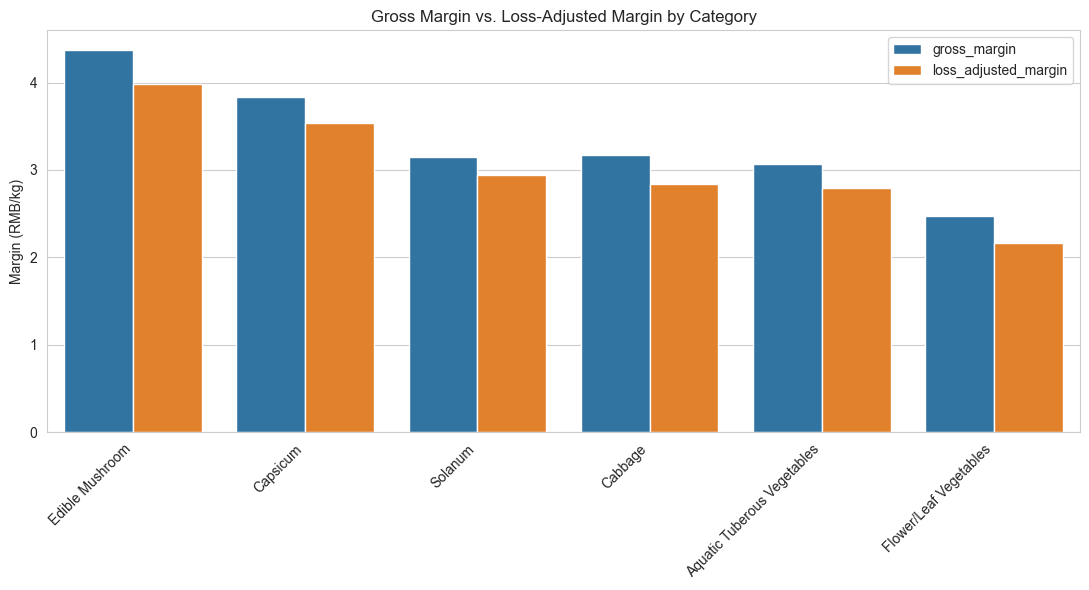

In [47]:
# Visualizing the gross margin vs. loss-adjusted margin by category
category_margins = con.sql("""
    WITH item_level AS (
        SELECT 
            c."Category Name",
            t."Unit Selling Price (RMB/kg)" AS sale_price,
            w."Wholesale Price (RMB/kg)" AS wholesale_cost,
            l."Loss Rate (%)" AS loss_rate_pct
        FROM transactions t
        JOIN category c ON t."Item Code" = c."Item Code"
        JOIN wholesale w ON t."Item Code" = w."Item Code" AND t."Date" = w."Date"
        JOIN loss_rate l ON t."Item Code" = l."Item Code"
        WHERE t."Sale or Return" = 'sale'
          AND t."Item Code" NOT IN (106930274620090, 106971533450003)
    )
    SELECT 
        "Category Name",
        AVG(sale_price) - AVG(wholesale_cost) AS gross_margin,
        (AVG(sale_price) - AVG(wholesale_cost)) * (1 - AVG(loss_rate_pct) / 100) AS loss_adjusted_margin
    FROM item_level
    GROUP BY "Category Name"
    ORDER BY loss_adjusted_margin DESC
""").df()

# Reshape for a grouped bar chart
melted = category_margins.melt(id_vars="Category Name", 
                                 value_vars=["gross_margin", "loss_adjusted_margin"],
                                 var_name="Margin Type", value_name="RMB/kg")

plt.figure(figsize=(11, 6))
sns.barplot(data=melted, x="Category Name", y="RMB/kg", hue="Margin Type")
plt.xticks(rotation=45, ha='right')
plt.title("Gross Margin vs. Loss-Adjusted Margin by Category")
plt.ylabel("Margin (RMB/kg)")
plt.xlabel("")
plt.legend(title="")
plt.tight_layout()
plt.show()

/var/folders/_d/1tsy_brx0qvf3p447snbp4mh0000gn/T/ipykernel_38756/1572653677.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=erosion, x="margin_erosion_pct", y="Category Name",


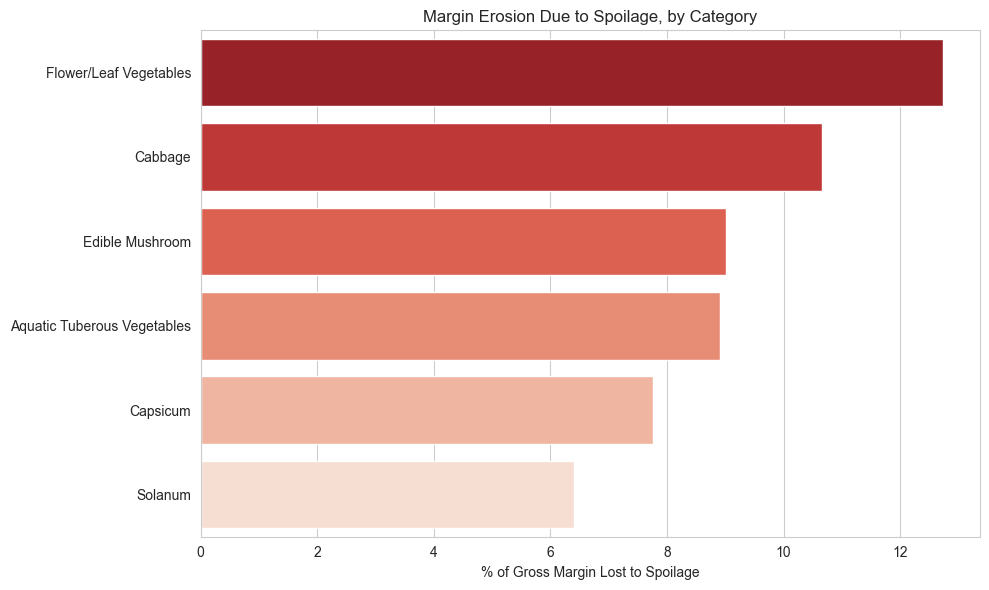

In [48]:
# Visualizing the erosion of margin due to spoilage by category
erosion = con.sql("""
    WITH item_level AS (
        SELECT 
            c."Category Name",
            t."Unit Selling Price (RMB/kg)" AS sale_price,
            w."Wholesale Price (RMB/kg)" AS wholesale_cost,
            l."Loss Rate (%)" AS loss_rate_pct
        FROM transactions t
        JOIN category c ON t."Item Code" = c."Item Code"
        JOIN wholesale w ON t."Item Code" = w."Item Code" AND t."Date" = w."Date"
        JOIN loss_rate l ON t."Item Code" = l."Item Code"
        WHERE t."Sale or Return" = 'sale'
          AND t."Item Code" NOT IN (106930274620090, 106971533450003)
    ),
    category_margins AS (
        SELECT 
            "Category Name",
            AVG(sale_price) - AVG(wholesale_cost) AS gross_margin,
            (AVG(sale_price) - AVG(wholesale_cost)) * (1 - AVG(loss_rate_pct) / 100) AS loss_adjusted_margin
        FROM item_level
        GROUP BY "Category Name"
    )
    SELECT 
        "Category Name",
        (gross_margin - loss_adjusted_margin) / gross_margin * 100 AS margin_erosion_pct
    FROM category_margins
    ORDER BY margin_erosion_pct DESC
""").df()

plt.figure(figsize=(10, 6))
sns.barplot(data=erosion, x="margin_erosion_pct", y="Category Name", 
            order=erosion.sort_values("margin_erosion_pct", ascending=False)["Category Name"],
            palette="Reds_r")
plt.title("Margin Erosion Due to Spoilage, by Category")
plt.xlabel("% of Gross Margin Lost to Spoilage")
plt.ylabel("")
plt.tight_layout()
plt.show()

/var/folders/_d/1tsy_brx0qvf3p447snbp4mh0000gn/T/ipykernel_38756/3942576257.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=revenue_lost, x="estimated_revenue_lost", y="Category Name",


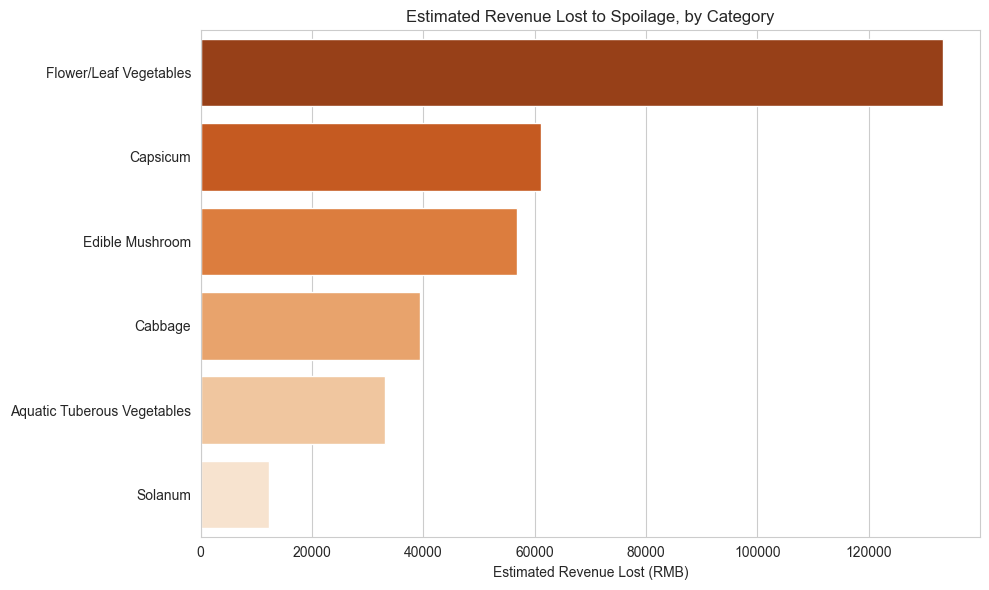

In [49]:
# Visualizing the estimated revenue lost to spoilage by category
revenue_lost = con.sql("""
    SELECT 
        c."Category Name",
        SUM(t."Quantity Sold (kilo)" * t."Unit Selling Price (RMB/kg)" * (l."Loss Rate (%)" / 100)) AS estimated_revenue_lost
    FROM transactions t
    JOIN category c ON t."Item Code" = c."Item Code"
    JOIN loss_rate l ON t."Item Code" = l."Item Code"
    WHERE t."Sale or Return" = 'sale' AND t."Item Code" NOT IN (106930274620090, 106971533450003)
    GROUP BY c."Category Name"
    ORDER BY estimated_revenue_lost DESC
""").df()

plt.figure(figsize=(10, 6))
sns.barplot(data=revenue_lost, x="estimated_revenue_lost", y="Category Name",
            order=revenue_lost.sort_values("estimated_revenue_lost", ascending=False)["Category Name"],
            palette="Oranges_r")
plt.title("Estimated Revenue Lost to Spoilage, by Category")
plt.xlabel("Estimated Revenue Lost (RMB)")
plt.ylabel("")
plt.tight_layout()
plt.show()

/var/folders/_d/1tsy_brx0qvf3p447snbp4mh0000gn/T/ipykernel_38756/2077459164.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_erosion, x="margin_erosion_pct", y="Item Name",


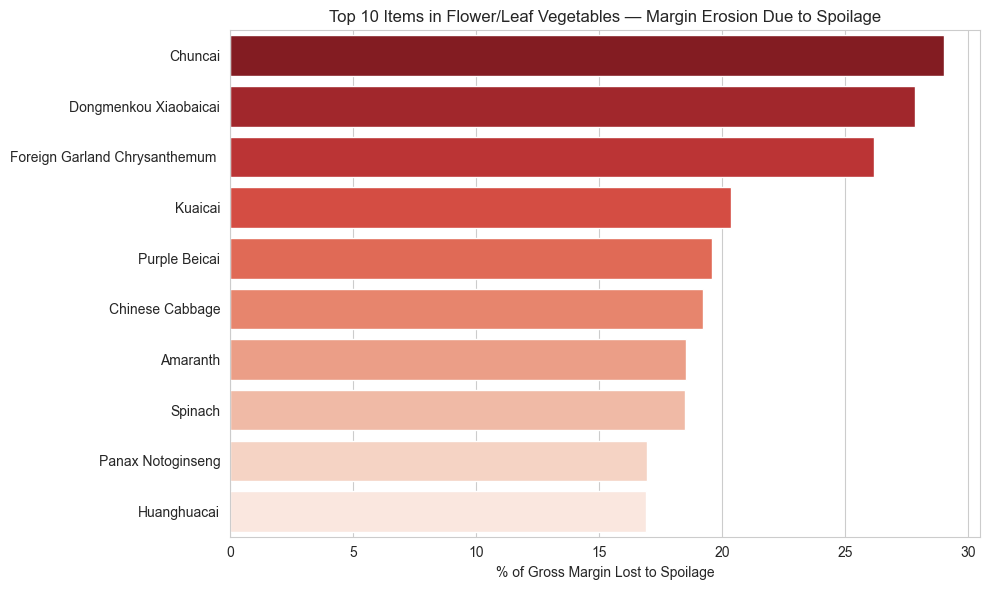

In [50]:
# Visualizing the top 10 items in Flower/Leaf Vegetables category ranked by margin erosion percentage
top10_erosion = con.sql("""
    WITH item_level AS (
        SELECT 
            c."Item Name",
            AVG(t."Unit Selling Price (RMB/kg)") AS avg_sale_price,
            AVG(w."Wholesale Price (RMB/kg)") AS avg_wholesale_cost,
            AVG(l."Loss Rate (%)") AS avg_loss_rate_pct
        FROM transactions t
        JOIN category c ON t."Item Code" = c."Item Code"
        JOIN wholesale w ON t."Item Code" = w."Item Code" AND t."Date" = w."Date"
        JOIN loss_rate l ON t."Item Code" = l."Item Code"
        WHERE t."Sale or Return" = 'sale'
          AND c."Category Name" LIKE '%Flower%Leaf%'
          AND t."Item Code" NOT IN (106930274620090, 106971533450003)
        GROUP BY c."Item Name"
    ),
    item_margins AS (
        SELECT
            "Item Name",
            avg_sale_price,
            avg_wholesale_cost,
            avg_loss_rate_pct,
            (avg_sale_price - avg_wholesale_cost) AS gross_margin,
            (avg_sale_price - avg_wholesale_cost) * (1 - avg_loss_rate_pct / 100) AS loss_adjusted_margin
        FROM item_level
    )
    SELECT
        "Item Name",
        gross_margin,
        loss_adjusted_margin,
        gross_margin - loss_adjusted_margin AS margin_erosion,
        (gross_margin - loss_adjusted_margin) / gross_margin * 100 AS margin_erosion_pct
    FROM item_margins
    ORDER BY margin_erosion_pct DESC
    LIMIT 10
""").df()

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=top10_erosion, x="margin_erosion_pct", y="Item Name",
            order=top10_erosion.sort_values("margin_erosion_pct", ascending=False)["Item Name"],
            palette="Reds_r")
plt.title("Top 10 Items in Flower/Leaf Vegetables — Margin Erosion Due to Spoilage")
plt.xlabel("% of Gross Margin Lost to Spoilage")
plt.ylabel("")
plt.tight_layout()
plt.show()

/var/folders/_d/1tsy_brx0qvf3p447snbp4mh0000gn/T/ipykernel_38756/1094798615.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_global_erosion, x="margin_erosion_pct", y="Item Name",


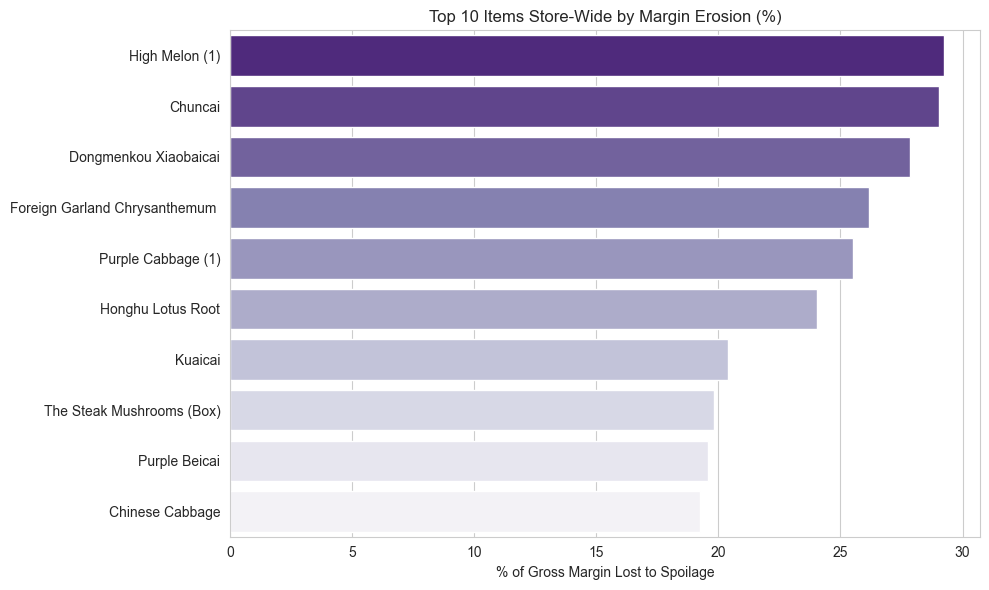

In [51]:
# Visualizing the top 10 items store-wide by margin erosion (% of gross margin lost to spoilage)
top10_global_erosion = con.sql("""
    WITH item_level AS (
        SELECT 
            c."Item Name",
            c."Category Name",
            AVG(t."Unit Selling Price (RMB/kg)") AS avg_sale_price,
            AVG(w."Wholesale Price (RMB/kg)") AS avg_wholesale_cost,
            AVG(l."Loss Rate (%)") AS avg_loss_rate_pct
        FROM transactions t
        JOIN category c ON t."Item Code" = c."Item Code"
        JOIN wholesale w ON t."Item Code" = w."Item Code" AND t."Date" = w."Date"
        JOIN loss_rate l ON t."Item Code" = l."Item Code"
        WHERE t."Sale or Return" = 'sale'
          AND t."Item Code" NOT IN (106930274620090, 106971533450003)
        GROUP BY c."Item Name", c."Category Name"
    ),
    item_margins AS (
        SELECT
            "Item Name",
            "Category Name",
            avg_sale_price,
            avg_wholesale_cost,
            avg_loss_rate_pct,
            (avg_sale_price - avg_wholesale_cost) AS gross_margin,
            (avg_sale_price - avg_wholesale_cost) * (1 - avg_loss_rate_pct / 100) AS loss_adjusted_margin
        FROM item_level
    )
    SELECT
        "Item Name",
        "Category Name",
        gross_margin,
        loss_adjusted_margin,
        gross_margin - loss_adjusted_margin AS margin_erosion,
        (gross_margin - loss_adjusted_margin) / gross_margin * 100 AS margin_erosion_pct
    FROM item_margins
    ORDER BY margin_erosion_pct DESC
    LIMIT 10
""").df()

plt.figure(figsize=(10, 6))
sns.barplot(data=top10_global_erosion, x="margin_erosion_pct", y="Item Name",
            order=top10_global_erosion.sort_values("margin_erosion_pct", ascending=False)["Item Name"],
            palette="Purples_r")  # different color from chart 5 to visually distinguish "global" from "category drill-down"
plt.title("Top 10 Items Store-Wide by Margin Erosion (%)")
plt.xlabel("% of Gross Margin Lost to Spoilage")
plt.ylabel("")
plt.tight_layout()
plt.show()